In [1]:
import sys, os
sys.path.append("../")

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import qmax as qx

from miscutils.plot import animate

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import Image

In [7]:
x0 = -10
xf = 10 
num_steps = 1000
num_modes = 250

hilbert_space = qx.spaces.PseudoSpectral(x0, xf, num_steps, num_modes)

k = 4
objective = lambda x: 0.5 * x ** 2
vals = hilbert_space.eval(objective)

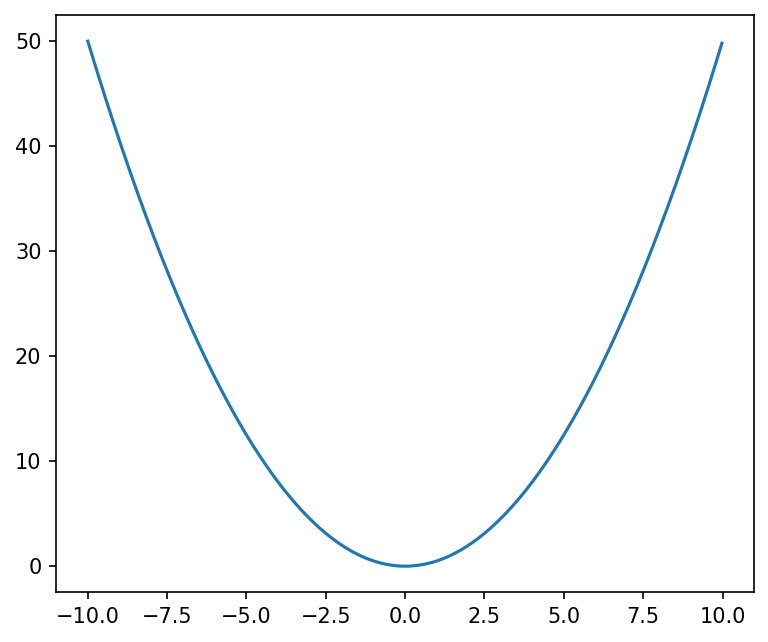

In [8]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

ax.plot(hilbert_space.x_range, vals)

plt.show()
plt.close(fig)

In [34]:
#y_vals = (1 + 1j) * jnp.ones_like(hilbert_space.x_range) / jnp.sqrt(2)
y_vals = jnp.exp(-0.5 * (hilbert_space.x_range + 5.0) ** 2)

y = hilbert_space.from_values(y_vals)

In [69]:
sys = qx.system.QuantumHamiltonianDescent(objective, hilbert_space)

t0 = 1.0
tf = 25.0
dt = 0.01

offset = 20
num_steps = 250
dt_range = 1.0 / jnp.arange(offset, num_steps + offset, 0.1)

t0 + jnp.cumsum(dt_range)

Array([ 1.05      ,  1.09975124,  1.14925619, ..., 27.0426542 ,
       27.04636065, 27.05006572], dtype=float64)

In [70]:
%time ys, t_range = sys.propagate(t0, tf, dt, y, qx.timestepper.Midpoint())
#%time ys, t_range = sys.propagate_dt_range(t0, dt_range, y, qx.timestepper.Midpoint())

CPU times: user 270 ms, sys: 35.4 ms, total: 305 ms
Wall time: 394 ms


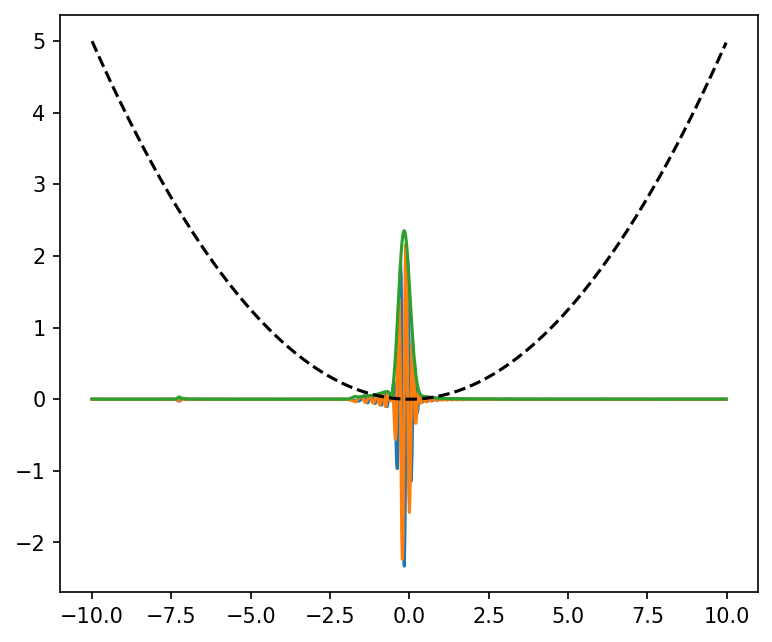

In [71]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

scale = 0.1
ax.plot(hilbert_space.x_range, jnp.real(ys[-1].values))
ax.plot(hilbert_space.x_range, jnp.imag(ys[-1].values))
ax.plot(hilbert_space.x_range, jnp.abs(ys[-1].values))
ax.plot(hilbert_space.x_range, scale * vals, "k--")

plt.show()
plt.close(fig)

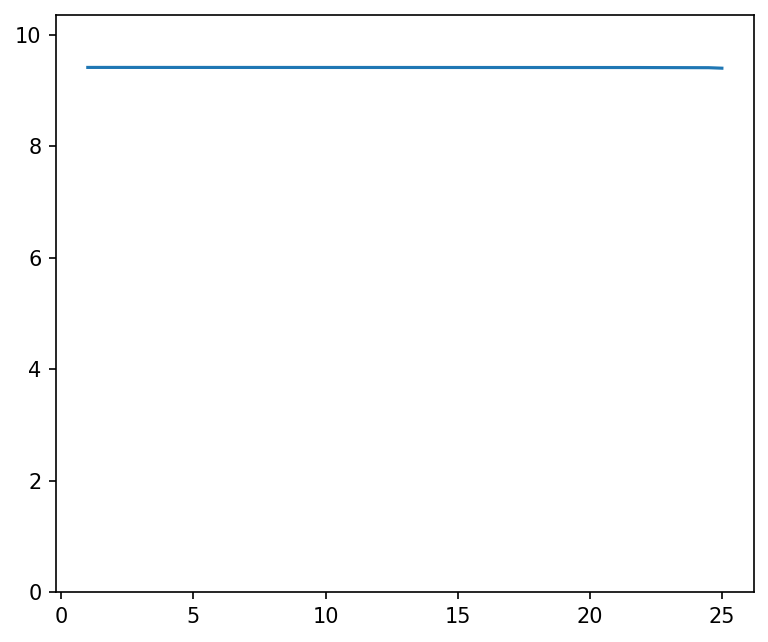

In [72]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

ax.plot(t_range, jnp.linalg.norm(ys.values, axis=1))

ax.set_ylim([0, 1.1 * jnp.linalg.norm(ys[0].values)])
plt.show()
plt.close(fig)

CPU times: user 14.1 s, sys: 181 ms, total: 14.3 s
Wall time: 14.2 s


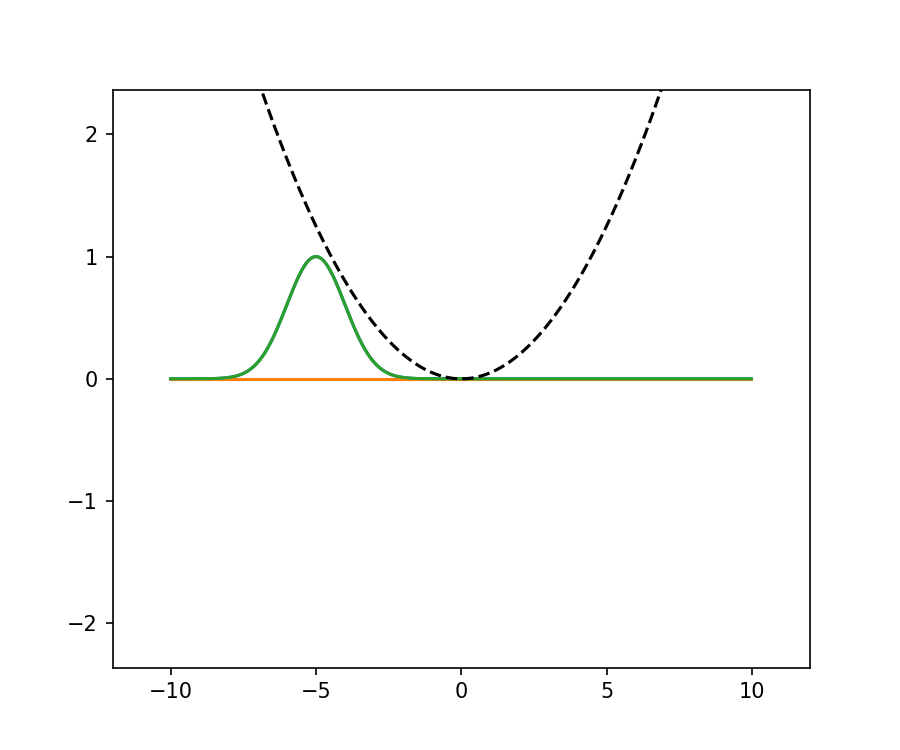

In [74]:
n = 8

def func(idx, ax, state, args):
    y_vals = ys[n * idx].values

    ax.plot(hilbert_space.x_range, jnp.real(y_vals))
    ax.plot(hilbert_space.x_range, jnp.imag(y_vals))
    ax.plot(hilbert_space.x_range, jnp.abs(y_vals))
    ax.plot(hilbert_space.x_range, scale * vals, "k--")

    ax.set_xlim([-12, 12])
    ax.set_ylim([jnp.min(jnp.real(ys.values)), jnp.max(jnp.real(ys.values))])

%time animate(func, t_range.shape[0] // n, filename="output.gif")